In [1]:
%load_ext autoreload
%autoreload 2

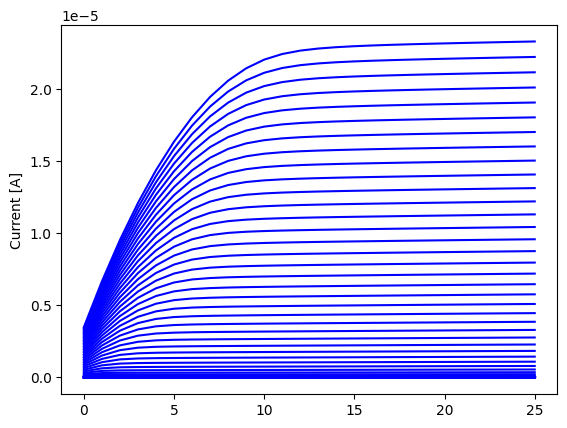

100%|██████████| 10000/10000 [05:28<00:00, 30.43it/s]


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import logging
from tqdm import tqdm
from src.get_first_device import get_first_device
from src.get_seperated_curves import get_seperated_curves
from src.plot_curves import plot_curves
from src.encoder import Encoder
from src.decoder import Decoder
from src.set_logger import set_logger
from src.get_reconstruction_loss import get_reconstruction_loss

CSV_FILE = "nmos_gaussian_l_vth_rds.csv"
SEP = "\t"
DEVICE_DIM = 1378
CURRENT_COL = 4
VOLTAGE_0_DIM = 53
VOLTAGE_1_DIM = 26
LEARNING_RATE = 2e-4
EPOCHS = 10_000
LOGGING_FILE = "logs.log"
LOGGER_LEVEL = logging.INFO 

dataframe = pd.read_csv(CSV_FILE, sep=SEP, header=None)
logger = set_logger(LOGGING_FILE, LOGGER_LEVEL)

# Get first device data
first_device_data = get_first_device(dataframe, DEVICE_DIM, CURRENT_COL)
separated_curves = get_seperated_curves(first_device_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)

encoder = Encoder()
decoder = Decoder()

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LEARNING_RATE
)

first_device_data_tensor = torch.tensor(first_device_data, dtype=torch.float32)
mse_loss = torch.nn.MSELoss()

loss_list = []
for epoch in tqdm(range(EPOCHS)):
    latent_data = encoder(first_device_data_tensor)
    output_data = decoder(latent_data)

    loss = get_reconstruction_loss(output_data, first_device_data_tensor)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if epoch % 100 == 0:
        logger.info(f"EPOCH: {epoch} LOSS: {loss.item()}")

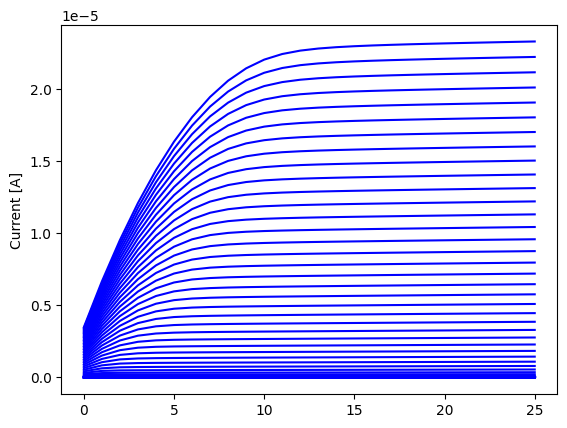

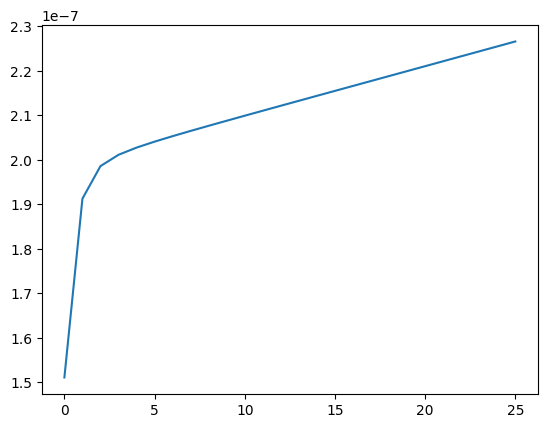

In [11]:
encoder.eval()
decoder.eval()

with torch.no_grad():
    encoded_data = encoder(first_device_data_tensor)
    decoded_data = decoder(encoded_data)

decoded_data = decoded_data.numpy()
separated_curves = get_seperated_curves(decoded_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
plt.plot(separated_curves[20])
plt.show()